In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"
    
from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

# our frmes of intrest are only
er = e[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

# ds
ds = cd[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

er[np.isnan(er)] = 90
ds[np.isnan(ds)] = 0

# min max scale err
er = er / 180

emissions = jnp.array(np.stack([ds, er], axis=-1))

subset_idx = np.random.choice(np.arange(0, len(emissions)), 400, replace=False)
sub_em = emissions[subset_idx]

er.shape, np.isnan(er).any(), ds.shape, np.isnan(ds).any(), emissions.shape

((34560, 239), np.False_, (34560, 239), np.False_, (34560, 239, 2))

## Loading the model params

In [4]:
with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)

In [5]:
with open('./caches/crossval_results.pkl', 'rb') as f:
    crossval_results = pickle.load(f)

# VAL VIZ

## Viz crossval

In [6]:
all_cv = []
all_ll = []

for idx in crossval_results.keys():
    sb = []
    ll = []
    for nstate in crossval_results[idx].keys():
        sb.append(crossval_results[idx][nstate].mean())
        ll.append(crossval_results[idx][nstate])
    all_cv.append(sb)
    all_ll.append(ll)

all_cv = np.array(all_cv)
all_ll = np.array(all_ll)

In [7]:
all_ll.shape

(12, 8, 100)

/tmp/ipykernel_101261/1273252595.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


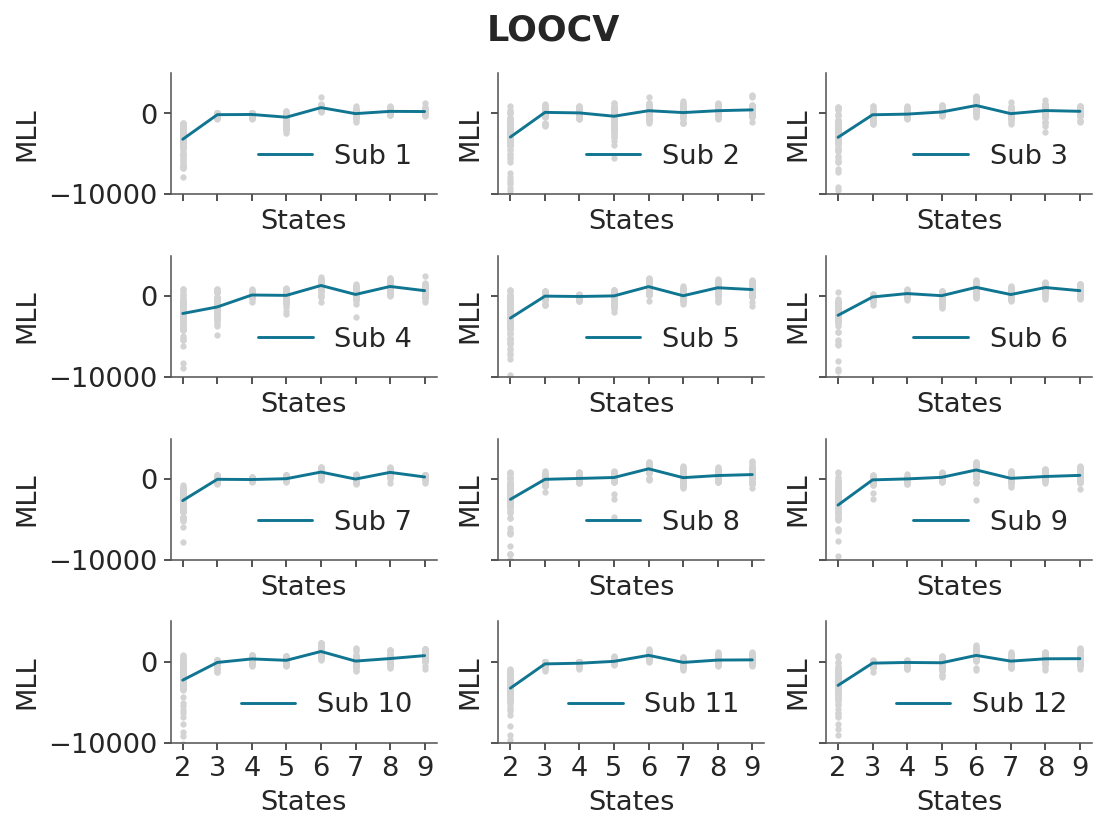

In [8]:

fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

for idx, subjects in enumerate(all_ll):
    for x in np.arange(2, 10):
        ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, subjects in enumerate(all_cv):
    # plt.plot(np.arange(2, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(2, 10), subjects, alpha=1, label=f"Sub {idx+1}")
    ax[idx].legend(frameon=False, loc="lower right")
    ax[idx].set_xticks(np.arange(2, 10))
    
    ax[idx].set_ylim(-10000,5000)
    
    ax[idx].set_ylabel("MLL")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

plt.tight_layout()

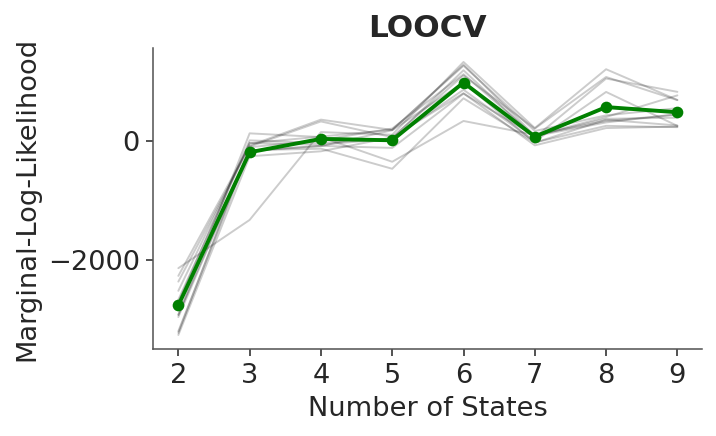

In [9]:
plt.figure(figsize=(5, 3))

# for subjects in all_ll:
#     for x in np.arange(2, 10):
#         plt.scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=0.05, color="lightgray")

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(2, 10), subjects, "-k", alpha=0.2, linewidth=1)
    # plt.plot(np.arange(2, 10), subjects, alpha=1, label=f"{idx+1}")

plt.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="Mean", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(2, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

# plt.legend()
plt.show()

## AIC, Bic of cross val

In [10]:
all_aic, all_bic = [], []
for idx, subjects in enumerate(all_ll):
    aic, bic = [], []
    for i, (n_state, ll) in enumerate(zip(np.arange(2,10), subjects)):
        T = 239
        edim = 2
        a, b = calc_aic_bic_ghmm(n_state, ll, edim, T)
        # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
        aic.append(a)
        bic.append(b)
    all_aic.append(aic)
    all_bic.append(bic)
all_aic, all_bic = np.array(all_aic), np.array(all_bic)

/tmp/ipykernel_101261/2968323393.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


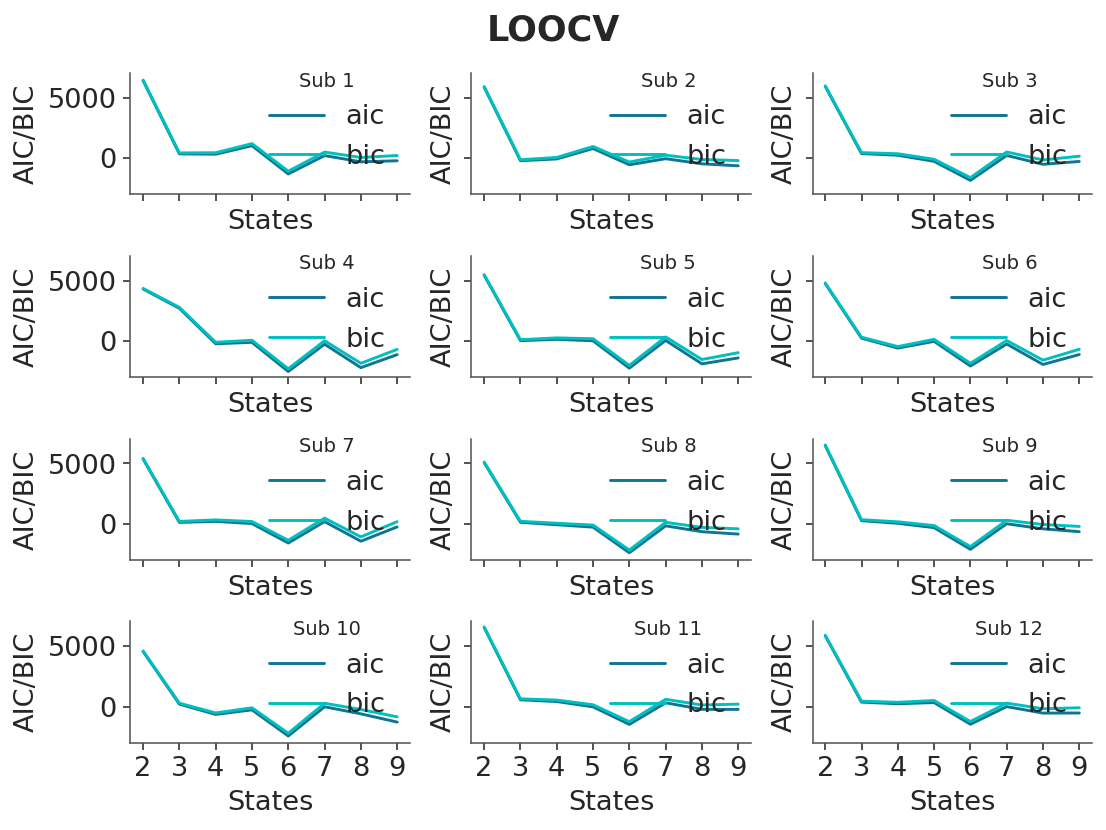

In [11]:
fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

# for idx, subjects in enumerate(all_ll):
#     for x in np.arange(2, 10):
#         ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, (aic, bic) in enumerate(zip(all_aic, all_bic)):
    # plt.plot(np.arange(2, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(2, 10), aic.mean(axis=1), alpha=1, label=f"aic")
    ax[idx].plot(np.arange(2, 10), bic.mean(axis=1), alpha=1, label=f"bic")
    
    ax[idx].legend(frameon=False, loc="lower right", title = f"Sub {idx+1}")
    ax[idx].set_xticks(np.arange(2, 10))
    
    ax[idx].set_ylabel("AIC/BIC")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

plt.tight_layout()

In [12]:
all_cv.shape, all_aic.shape, all_bic.shape

((12, 8), (12, 8, 100), (12, 8, 100))

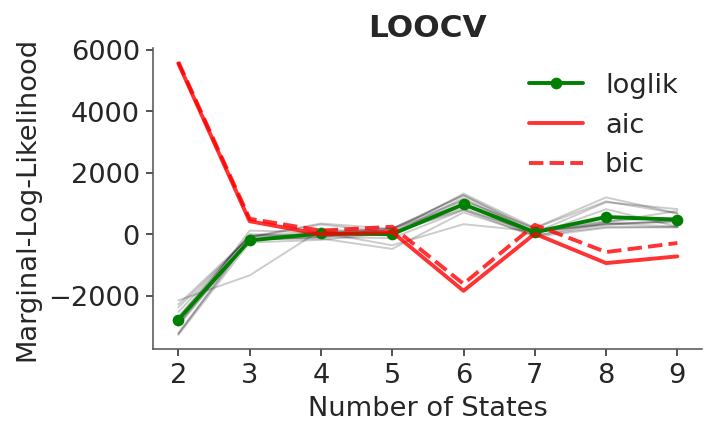

In [13]:
plt.figure(figsize=(5, 3))

# for subjects in all_ll:
#     for x in np.arange(2, 10):
#         plt.scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=0.05, color="lightgray")

for idx, subjects in enumerate(all_cv):
    plt.plot(np.arange(2, 10), subjects, "-k", alpha=0.2, linewidth=1)
    # plt.plot(np.arange(2, 10), subjects, alpha=1, label=f"{idx+1}")

plt.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-go", alpha=1, label="loglik", linewidth=2, markersize=5)
plt.plot(np.arange(2, 10), np.array(all_aic).mean(axis=(0,2)), "-r", alpha=.8, label="aic", linewidth=2, markersize=5)
plt.plot(np.arange(2, 10), np.array(all_bic).mean(axis=(0,2)), "--r", alpha=.8, label="bic", linewidth=2, markersize=5)

plt.xlabel("Number of States")
plt.ylabel("Marginal-Log-Likelihood")
plt.xticks(np.arange(2, 10))
plt.title("LOOCV")

# plt.ylim(-250, 1570)

plt.legend()
plt.show()

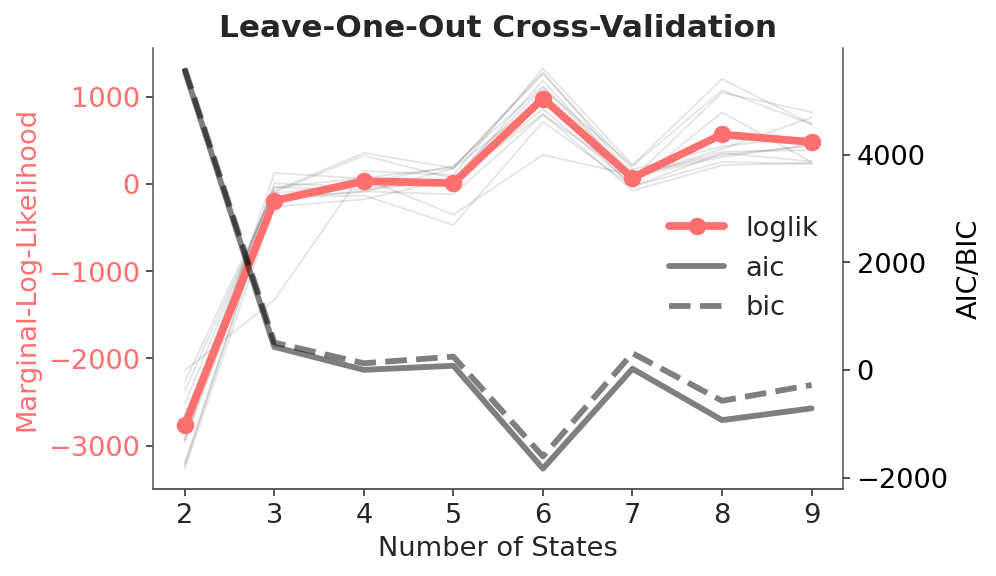

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot each individual log-likelihood curve on ax1 (left axis)
for subjects in all_cv:
    ax1.plot(np.arange(2, 10), subjects, "-k", alpha=0.1, linewidth=1)

# Plot the mean log-likelihood on ax1 in green
ax1.plot(np.arange(2, 10), np.array(all_cv).mean(axis=0), "-o", color="#fe7070",
         alpha=1, label="loglik", linewidth=4, markersize=8)
ax1.set_xlabel("Number of States")
ax1.set_ylabel("Marginal-Log-Likelihood", color="#fe7070")
ax1.tick_params(axis='y', labelcolor="#fe7070")
ax1.set_xticks(np.arange(2, 10))
ax1.set_title("Leave-One-Out Cross-Validation")

# Create a second y-axis sharing the same x-axis for AIC/BIC
ax2 = ax1.twinx()
ax2.plot(np.arange(2, 10), np.array(all_aic).mean(axis=(0,2)), "-k", 
         alpha=0.5, label="aic", linewidth=3, markersize=5)
ax2.plot(np.arange(2, 10), np.array(all_bic).mean(axis=(0,2)), "--k", 
         alpha=0.5, label="bic", linewidth=3, markersize=5)
ax2.set_ylabel("AIC/BIC", color="k")
ax2.tick_params(axis='y', labelcolor="k")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

# Axis border off
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.show()


# OCC viz

In [ ]:
st = 2
sb = 8
ts = subject_params[sb][st]
model = CircularRegressionHMM(st, input_dim, emission_dim)

In [ ]:
mls = []
for e, i in zip(emissions.reshape(12, 4 * 6, 120, 1)[sb]):
    most_likely_states = model.most_likely_states(ts, e)
    mls.append(most_likely_states)
    
mls = np.array(mls)

In [ ]:
# Count occurrences for each class (assuming classes 0, 1, 2)
counts = np.bincount(mls.flatten(), minlength=st)
proportions = counts / mls.size  # mls.size is 2880 in this case

print("Overall proportions:", proportions)

# PARAM VIZ

In [ ]:
plt.figure(figsize=(4,3))
sns.heatmap(ts.transitions.transition_matrix)